# Code testing notebook

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

In [2]:
sample = 'all_samples'
deepcsa_run_dir = '/data/bbg/nobackup/prominent/SantPauCH/deepCSA/sp_vhio/custom/2026-03-23_Sp_CHa_H_T0s_only_custom/'

In [5]:
fn = f"{deepcsa_run_dir}/processing_files/absolutemutabilitiesgloballoc/mutabilities_per_site.{sample}.global_loc.tsv.gz"
df = pd.read_csv(fn, sep='\t', compression='gzip')

In [9]:
df[df['GENE'] == 'TP53'].head(100)

,CHROM,POS,CONTEXT_MUT,GENE,IMPACT,all_samples
778632,chr17,7669609,GTC>A,TP53,nonsense,0.002483
778633,chr17,7669609,GTC>C,TP53,nonsense,0.004700
778634,chr17,7669609,GTC>G,TP53,nonsense,0.001533
778635,chr17,7669610,TCA>A,TP53,nonsense,0.002397
778636,chr17,7669610,TCA>G,TP53,nonsense,0.002312
...,...,...,...,...,...,...
778727,chr17,7669640,ATG>A,TP53,missense,0.003181
778728,chr17,7669641,ATG>A,TP53,missense,0.003171
778729,chr17,7669641,ATG>C,TP53,missense,0.008605
778730,chr17,7669641,ATG>G,TP53,missense,0.001779


In [37]:
print(list(df['GENE'].unique()))

['TNFRSF14', 'RPL22', 'MTOR', 'SPEN', 'ID3', 'ARID1A', 'ZC3H12A', 'JAK1', 'NRAS', 'TENT5C', 'NOTCH2', 'ELF3', 'BTG2', 'PIGR', 'H3-3A', 'RGS7', 'GATA3', 'ZEB1', 'RET', 'PTEN', 'TCF7L2', 'FGFR2', 'HRAS', 'WT1', 'MEN1', 'CCND1', 'FAT3', 'ATM', 'KMT2A', 'CBL', 'CHD4', 'CDKN1B', 'KRAS', 'ARID2', 'KMT2D', 'ERBB3', 'PTPRB', 'BTG1', 'PTPN11', 'TBX3', 'NCOR2', 'POLE', 'FLT3', 'BRCA2', 'RB1', 'AJUBA', 'FOXA1', 'MAX', 'DICER1', 'AKT1', 'MGA', 'B2M', 'MAP2K1', 'IDH2', 'AXIN1', 'TSC2', 'CREBBP', 'SOCS1', 'PRKCB', 'CYLD', 'CDH11', 'CBFB', 'CTCF', 'CDH1', 'ZFHX3', 'USP6', 'TP53', 'MAP2K4', 'NCOR1', 'NF1', 'SUZ12', 'CDK12', 'ERBB2', 'STAT3', 'BRCA1', 'SPOP', 'RNF43', 'PPM1D', 'GNA13', 'SOX9', 'SRSF2', 'SETBP1', 'SMAD2', 'SMAD4', 'DCC', 'BCL2', 'STK11', 'KEAP1', 'SMARCA4', 'NOTCH3', 'KMT2B', 'ERCC2', 'ARHGAP35', 'PPP2R1A', 'DNMT3A', 'ALK', 'BIRC6', 'MSH2', 'MSH6', 'PCBP1', 'CTNNA2', 'LRP1B', 'ACVR2A', 'NFE2L2', 'SF3B1', 'CASP8', 'IDH1', 'ERBB4', 'CUL3', 'FOXA2', 'ASXL1', 'GNAS', 'RUNX1', 'U2AF1', 'LZTR

In [39]:
def plot_mutabilities(gene):
    df_gene = df[df['GENE'] == gene]
    fig, ax = plt.subplots(figsize=(10, 6), nrows=3)
    for j, impact in enumerate(df_gene['IMPACT'].unique()):
        if impact in ['missense', 'nonsense', 'synonymous']:
            df_impact = df_gene[df_gene['IMPACT'] == impact]
            ax[j].hist(df_impact[sample].values, label=impact, bins=100, alpha=0.7)
            ax[j].legend()
            # ax[j].set_title(f'Mutabilities for {gene}')
            # ax[j].set_xscale('log')
            plt.xlim(0, 0.05)
    plt.show()
# g = df.groupby(['GENE', 'IMPACT']).agg({sample: list}).reset_index()
# g

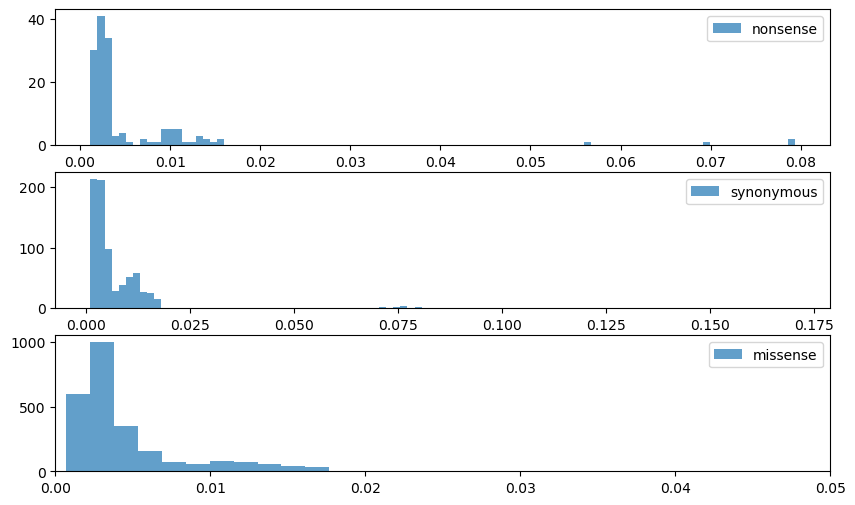

In [40]:
plot_mutabilities('TP53')

In [44]:
# profile adjusted mutdensities

fn = '/data/bbg/nobackup/prominent/SantPauCH/deepCSA/sp_vhio/custom/2026-03-23_Sp_CHa_H_T0s_only_custom/mutdensity_adjusted/all_adjusted_mutdensities.tsv'
fn = '/data/bbg/nobackup/prominent/SantPauCH/deepCSA/sp_vhio/synthetic/2026-04-14_synthetic_sp_vhio_custom07/mutdensity_adjusted/all_adjusted_mutdensities.tsv'
df = pd.read_csv(fn, sep='\t')

In [45]:
df

,GENE,SAMPLE,synonymous,missense,nonsense,essential_splice,truncating,nonsynonymous_splice,all_impacts
0,RGS7,all_samples_10_1_nonsense_079,0.181998,0.185599,1.001447,0.210157,0.697121,0.249798,0.235605
1,TCF7L2,all_samples_10_1_nonsense_079,0.046949,0.036226,0.375892,0.054712,0.267566,0.060175,0.056488
2,DICER1,all_samples_10_1_nonsense_079,0.046842,0.033067,0.175492,0.061188,0.154388,0.044427,0.044930
3,CDH1,all_samples_10_1_nonsense_079,0.106667,0.078764,0.542809,0.099667,0.394255,0.104097,0.104731
4,TP53,all_samples_10_1_nonsense_079,0.034656,0.027756,0.162074,0.000000,0.103588,0.034953,0.034887
...,...,...,...,...,...,...,...,...,...
18010,TERT,all_samples_10_1_nonsense_005,0.098087,0.072578,0.457834,0.150223,0.385981,0.093555,0.094811
18011,NSD1,all_samples_10_1_nonsense_005,0.055905,0.036591,0.273378,0.067103,0.245665,0.053130,0.053711
18012,EGFR,all_samples_10_1_nonsense_005,0.145497,0.117974,0.551034,0.142290,0.407842,0.144174,0.144484
18013,JAK2,all_samples_10_1_nonsense_005,0.034714,0.032970,0.328656,0.039702,0.242545,0.055617,0.051834


In [47]:
df['missense_dNdS'] = df['missense'] / df['synonymous']
df['nonsense_dNdS'] = df['nonsense'] / df['synonymous']
df

,GENE,SAMPLE,synonymous,missense,nonsense,essential_splice,truncating,nonsynonymous_splice,all_impacts,missense_dNdS,nonsense_dNdS
0,RGS7,all_samples_10_1_nonsense_079,0.181998,0.185599,1.001447,0.210157,0.697121,0.249798,0.235605,1.019784,5.502508
1,TCF7L2,all_samples_10_1_nonsense_079,0.046949,0.036226,0.375892,0.054712,0.267566,0.060175,0.056488,0.771592,8.006329
2,DICER1,all_samples_10_1_nonsense_079,0.046842,0.033067,0.175492,0.061188,0.154388,0.044427,0.044930,0.705912,3.746424
3,CDH1,all_samples_10_1_nonsense_079,0.106667,0.078764,0.542809,0.099667,0.394255,0.104097,0.104731,0.738409,5.088832
4,TP53,all_samples_10_1_nonsense_079,0.034656,0.027756,0.162074,0.000000,0.103588,0.034953,0.034887,0.800907,4.676611
...,...,...,...,...,...,...,...,...,...,...,...
18010,TERT,all_samples_10_1_nonsense_005,0.098087,0.072578,0.457834,0.150223,0.385981,0.093555,0.094811,0.739931,4.667619
18011,NSD1,all_samples_10_1_nonsense_005,0.055905,0.036591,0.273378,0.067103,0.245665,0.053130,0.053711,0.654515,4.890023
18012,EGFR,all_samples_10_1_nonsense_005,0.145497,0.117974,0.551034,0.142290,0.407842,0.144174,0.144484,0.810836,3.787261
18013,JAK2,all_samples_10_1_nonsense_005,0.034714,0.032970,0.328656,0.039702,0.242545,0.055617,0.051834,0.949743,9.467479


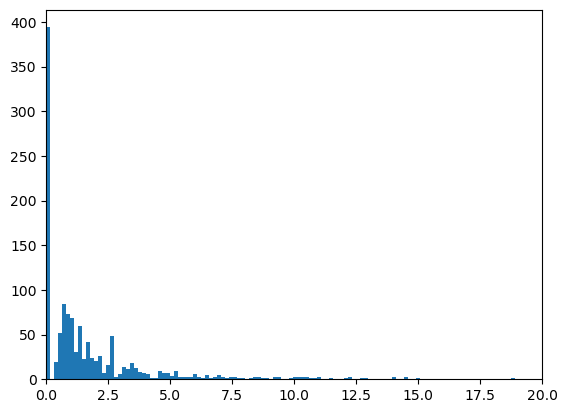

In [66]:
v = df[df['GENE'] == 'TP53']['nonsense_dNdS'].values
v = v[~np.isinf(v)]
plt.hist(v, bins=200)
plt.xlim(0, 20)
plt.show()

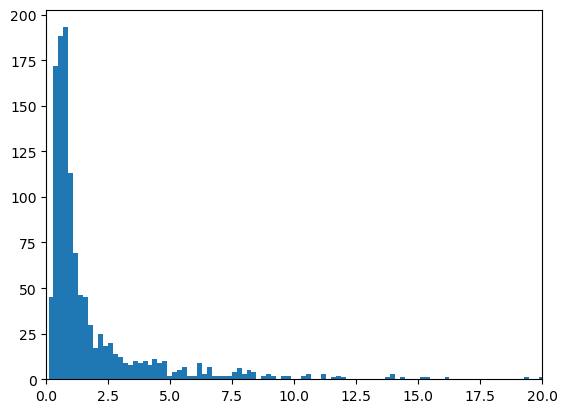

In [67]:
v = df[df['GENE'] == 'TP53']['missense_dNdS'].values
v = v[~np.isinf(v)]
plt.hist(v, bins=200)
plt.xlim(0, 20)
plt.show()